In [1]:
min_lon, min_lat = 86.582, 27.770
max_lon, max_lat = 86.989, 28.041

In [2]:
from pyproj import Transformer

In [3]:
gps_to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32645", always_xy=True)
min_x, min_y = gps_to_utm.transform(min_lon, min_lat)
max_x, max_y = gps_to_utm.transform(max_lon, max_lat)

We need to sample the DEM data using a grid of 500m x 500m.

In [4]:
grid_spacing = 500.0

In [5]:
import numpy as np

In [6]:
X_v = np.arange(min_x, max_x, grid_spacing)
Y_v = np.arange(min_y, max_y, grid_spacing)

In [7]:
X_v

array([458814.04457295, 459314.04457295, 459814.04457295, 460314.04457295,
       460814.04457295, 461314.04457295, 461814.04457295, 462314.04457295,
       462814.04457295, 463314.04457295, 463814.04457295, 464314.04457295,
       464814.04457295, 465314.04457295, 465814.04457295, 466314.04457295,
       466814.04457295, 467314.04457295, 467814.04457295, 468314.04457295,
       468814.04457295, 469314.04457295, 469814.04457295, 470314.04457295,
       470814.04457295, 471314.04457295, 471814.04457295, 472314.04457295,
       472814.04457295, 473314.04457295, 473814.04457295, 474314.04457295,
       474814.04457295, 475314.04457295, 475814.04457295, 476314.04457295,
       476814.04457295, 477314.04457295, 477814.04457295, 478314.04457295,
       478814.04457295, 479314.04457295, 479814.04457295, 480314.04457295,
       480814.04457295, 481314.04457295, 481814.04457295, 482314.04457295,
       482814.04457295, 483314.04457295, 483814.04457295, 484314.04457295,
       484814.04457295, 4

In [8]:
Y_v

array([3071794.51706792, 3072294.51706792, 3072794.51706792,
       3073294.51706792, 3073794.51706792, 3074294.51706792,
       3074794.51706792, 3075294.51706792, 3075794.51706792,
       3076294.51706792, 3076794.51706792, 3077294.51706792,
       3077794.51706792, 3078294.51706792, 3078794.51706792,
       3079294.51706792, 3079794.51706792, 3080294.51706792,
       3080794.51706792, 3081294.51706792, 3081794.51706792,
       3082294.51706792, 3082794.51706792, 3083294.51706792,
       3083794.51706792, 3084294.51706792, 3084794.51706792,
       3085294.51706792, 3085794.51706792, 3086294.51706792,
       3086794.51706792, 3087294.51706792, 3087794.51706792,
       3088294.51706792, 3088794.51706792, 3089294.51706792,
       3089794.51706792, 3090294.51706792, 3090794.51706792,
       3091294.51706792, 3091794.51706792, 3092294.51706792,
       3092794.51706792, 3093294.51706792, 3093794.51706792,
       3094294.51706792, 3094794.51706792, 3095294.51706792,
       3095794.51706792,

In [9]:
total_viewpoints = Y_v.shape[0] * X_v.shape[0]
print(f"No. of viewpoints = {total_viewpoints}")

No. of viewpoints = 4860


Example:

`X_v = x0, x1, x2, x3` <br/>
`Y_v = y0, y1`

We want to generate the entire grid i.e.
<br/>`view_x = [x0, x0, x1, x1, x2, x2, x3, x3]`
<br/>`view_y = [y0, y1, y0, y1, y0, y1, y0, y1]`
<br/> `view_xs_ys = [[x0, y0], [x0, y1], [x1, y0], [x1, y1], [x2, y0], [x2, y1], [x3, y0], [x3, y1]]`

In [10]:
view_xs, view_ys = np.meshgrid(X_v, Y_v)

In [11]:
view_xs_ys = np.column_stack((view_xs.ravel(), view_ys.ravel())).astype(np.float32)
view_xs_ys

array([[ 458814.03, 3071794.5 ],
       [ 459314.03, 3071794.5 ],
       [ 459814.03, 3071794.5 ],
       ...,
       [ 497814.03, 3101294.5 ],
       [ 498314.03, 3101294.5 ],
       [ 498814.03, 3101294.5 ]], shape=(4860, 2), dtype=float32)

We have the (x, y) of all viewpoints.

But, still we need to calculate the elevation the user'd be at if standing at those coordinates.

In [12]:
import rasterio

In [13]:
dem_file = "data/dem.tif" 

with rasterio.open(dem_file) as src:
    dem_data = src.read(1).astype(np.float32)
    [pixel_width, row_rotation, start_x, col_rotation, pixel_height, start_y] = src.transform[:6]

    xs = start_x + np.arange(src.width) * pixel_width
    ys = start_y + np.arange(src.height) * pixel_height

In [14]:
xs

array([378814.04457295, 378844.04457295, 378874.04457295, ...,
       578824.04457295, 578854.04457295, 578884.04457295], shape=(6670,))

In [15]:
ys

array([3181744.2130676, 3181714.2130676, 3181684.2130676, ...,
       2991874.2130676, 2991844.2130676, 2991814.2130676], shape=(6332,))

xs seems to be increasing. ys seems to be decreasing. HORAYZON expects both axes to be increasing.

In [16]:
if pixel_height < 0:
    ys = ys[::-1]
    pixel_height *= -1
    dem_data = np.flipud(dem_data)

In [17]:
ys

array([2991814.2130676, 2991844.2130676, 2991874.2130676, ...,
       3181684.2130676, 3181714.2130676, 3181744.2130676], shape=(6332,))

In [18]:
dem_data

array([[ 246.77638,  247.56421,  248.97066, ..., 1894.6173 , 1905.0948 ,
        1915.6089 ],
       [ 246.34021,  246.46156,  245.92365, ..., 1901.7035 , 1913.6661 ,
        1924.1322 ],
       [ 247.44736,  247.0493 ,  246.93039, ..., 1900.4663 , 1914.6925 ,
        1927.5096 ],
       ...,
       [4654.92   , 4654.2944 , 4654.405  , ..., 4907.0034 , 4897.9263 ,
        4889.411  ],
       [4654.688  , 4654.201  , 4654.243  , ..., 4906.8184 , 4899.095  ,
        4890.7915 ],
       [4653.902  , 4653.649  , 4653.836  , ..., 4906.4277 , 4900.396  ,
        4891.837  ]], shape=(6332, 6670), dtype=float32)

In [19]:
view_cols = np.round((view_xs_ys[:, 0] - start_x) / pixel_width).astype(int)
view_rows = np.round((view_xs_ys[:, 1] - start_y) / pixel_height).astype(int)
view_zs = dem_data[view_rows, view_cols].astype(np.float32)

viewpoints = np.column_stack((view_xs_ys, view_zs)).astype(np.float32)
viewpoints

array([[ 458814.03  , 3071794.5   ,    5152.5703],
       [ 459314.03  , 3071794.5   ,    5034.336 ],
       [ 459814.03  , 3071794.5   ,    5221.4272],
       ...,
       [ 497814.03  , 3101294.5   ,    6685.4897],
       [ 498314.03  , 3101294.5   ,    6471.0015],
       [ 498814.03  , 3101294.5   ,    6190.0776]],
      shape=(4860, 3), dtype=float32)

From each viewpoint, we'll raycast in each azimuth using progressive search radii.

In [20]:
max_search_radii = {
    "global": 80.0,     #km
    "local": 15.0,      #km
    "restricted": 3.0   #km
}

In [21]:
azimuths = np.arange(0, 360, 0.25)
azimuths

array([0.0000e+00, 2.5000e-01, 5.0000e-01, ..., 3.5925e+02, 3.5950e+02,
       3.5975e+02], shape=(1440,))

In [22]:
num_rays = azimuths.shape[0]
print(f"No. of rays cast from each viewpoint = {num_rays}*3")

No. of rays cast from each viewpoint = 1440*3


HORAYZON requires a vertex grid (containing co-ordinate of each pixel) in `[X0, Y0, Z0, X1, Y1, Z1, ...]` format.

In [23]:
from horayzon import horizon
import horayzon as hray

In [24]:
vert_grid = hray.auxiliary.rearrange_pad_buffer(*np.meshgrid(xs.astype(np.float32), ys.astype(np.float32)), dem_data)
vert_grid

array([3.7881403e+05, 2.9918142e+06, 2.4677638e+02, ..., 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00], shape=(126703336,), dtype=float32)

This vert_grid can be helpful for synthetic data generation for training the sky segmentation model later on.

In [39]:
np.savez_compressed(
    "data/terrain_mesh.npz",
    vert_grid=vert_grid,
    height=np.array([src.height]),
    width=np.array([src.width])
)

We need a reference for the elevation angles.

We assume `vec_up` to be at $90^\circ$ azimuth angle.

In [25]:
vec_up = np.column_stack((np.zeros((total_viewpoints, 2)), np.ones(total_viewpoints))).astype(np.float32)
vec_up

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]], shape=(4860, 3), dtype=float32)

HORAYZON needs a reference for the azimuth angles.

We assume `vec_north` to be at $0^\circ$ azimuth angle.

In [26]:
vec_north = np.column_stack((np.zeros(total_viewpoints), np.ones(total_viewpoints), np.zeros(total_viewpoints))).astype(np.float32)
vec_north

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]], shape=(4860, 3), dtype=float32)

We never raycast from the ground itself.

We perform raycasting from a virtual camera at some height (generally taken as 1.8m).

In [27]:
ray_org_elev = np.full(total_viewpoints, 1.8, dtype=np.float32)
ray_org_elev

array([1.8, 1.8, 1.8, ..., 1.8, 1.8, 1.8], shape=(4860,), dtype=float32)

We'll be saving the horizons in files in data/ folder.

In [28]:
import os
os.makedirs("data", exist_ok=True)  # Create data folder if doesn't exist

In [29]:
for name, radius in max_search_radii.items():
    print(f"Casting {num_rays} rays from {total_viewpoints} viewpoints (Max Search Distance: {radius} km)...")
 
    horizon_elevation_angles, distance_to_horizon, _ = hray.horizon.horizon_locations(
        vert_grid,                   # 3D model of the DEM
        src.height,                  # Height of DEM image
        src.width,                   # Width of DEM image
        viewpoints,                  # Viewpoints
        vec_up,                      # Reference for elevation angle (90deg)
        vec_north,                   # Reference for azimuth angle (0deg)
        dist_search=radius,          # Search radius
        azim_num=num_rays,           # No. of azimuths to search
        hori_acc=0.1,                # Vertical accuracy
        ray_org_elev=ray_org_elev,   # Elevation of virtual camera
        hori_dist_out=True           # Compute distance to horizon
    )
    
    # Save the output to disk as a binary NumPy file (.npy) in degrees
    np.save(f"data/horizon_db_{name}.npy", np.degrees(horizon_elevation_angles))

    # Save the physical distances to horizon (in meters)
    np.save(f"data/horizon_dist_{name}.npy", np.degrees(distance_to_horizon))

Casting 1440 rays from 4860 viewpoints (Max Search Distance: 80.0 km)...
--------------------------------------------------------
Horizon computation with Intel Embree
--------------------------------------------------------
DEM dimensions: (6332, 6670) 
Number of vertices: 42234440 
Selected geometry type: grid
BVH build time: 0.982735 s
Total initialisation time: 0.985757 s
Number of locations for which horizon is computed: 4860 
Horizon detection algorithm: binary search
Ray tracing time: 3.90522 s
Number of rays shot: 73984111
Average number of rays per location and azimuth: 10.57 
Total run time: 4.90272 s
--------------------------------------------------------
Casting 1440 rays from 4860 viewpoints (Max Search Distance: 15.0 km)...
--------------------------------------------------------
Horizon computation with Intel Embree
--------------------------------------------------------
DEM dimensions: (6332, 6670) 
Number of vertices: 42234440 
Selected geometry type: grid
BVH build 

Let's try plotting a horizon from some random viewpoint.

In [32]:
import matplotlib.pyplot as plt

In [34]:
db_global = np.load("data/horizon_db_global.npy") 
db_global

array([[16.040003 , 15.940004 , 15.820003 , ..., 16.350004 , 16.350004 ,
        16.210003 ],
       [17.700005 , 17.700005 , 17.700005 , ..., 17.700005 , 17.700005 ,
        17.700005 ],
       [15.650003 , 15.650003 , 15.820003 , ..., 15.240003 , 15.340003 ,
        15.480003 ],
       ...,
       [ 9.490005 ,  9.490005 ,  9.310003 , ...,  9.720004 ,  9.620004 ,
         9.490005 ],
       [ 9.140003 ,  8.7800045,  8.610004 , ...,  9.720004 ,  9.490005 ,
         9.310003 ],
       [11.600003 , 11.600003 , 11.430003 , ..., 11.600003 , 11.600003 ,
        11.600003 ]], shape=(4860, 1440), dtype=float32)

In [35]:
# We chose 2400th viewpoint
viewpoint_idx = 2400 
horizon_profile = db_global[viewpoint_idx]

In [37]:
azimuths = np.linspace(0, 360, db_global.shape[1], endpoint=False)
azimuths

array([0.0000e+00, 2.5000e-01, 5.0000e-01, ..., 3.5925e+02, 3.5950e+02,
       3.5975e+02], shape=(1440,))

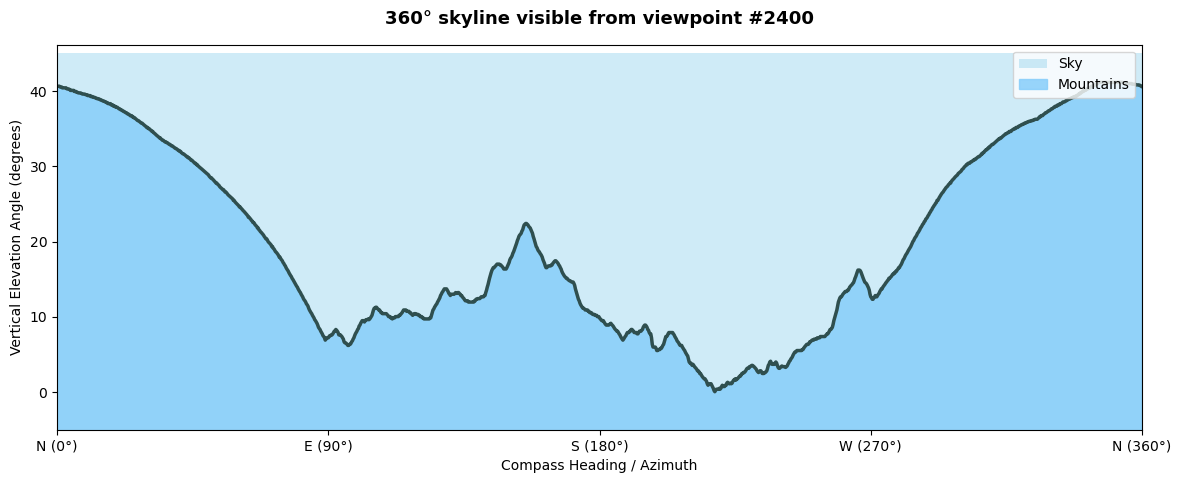

In [38]:
plt.figure(figsize=(14, 5))

# Paint the sky (light blue background)
plt.axhspan(-10, 45, facecolor='skyblue', alpha=0.4, label='Sky')

# Plot the sharp, physical skyline boundaries
plt.plot(azim_deg, horizon_profile, color='darkslategrey', lw=2.5)

# Fill the area below the skyline to represent the solid mountain terrain
plt.fill_between(azim_deg, -10, horizon_profile, color='lightskyblue', alpha=0.85, label='Mountains')

plt.title(f"360° skyline visible from viewpoint #{viewpoint_idx}", 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Compass Heading / Azimuth")
plt.ylabel("Vertical Elevation Angle (degrees)")

plt.xticks([0, 90, 180, 270, 360], ['N (0°)', 'E (90°)', 'S (180°)', 'W (270°)', 'N (360°)'])

plt.xlim(0, 360)
plt.ylim(-5, np.max(horizon_profile) + 5)

plt.legend(loc='upper right')

plt.show()